# 0. Preparação

In [40]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import cdist


In [41]:
df=pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [42]:
# Variáveis categóricas: OneHotEncoder porque nem occupation nem gender têm uma ordem natural
categorical_columns = ['occupation', 'gender']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

data = pd.concat([df, one_hot_df], axis=1)
data = data.drop(['occupation', 'gender'], axis=1)

#
---

# 1. Divisão do Stress Level

### 1.1 K-Means

In [43]:
#K-Means
def apply_kmeans(df, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df[['stress_level']])
    
    centroids = kmeans.cluster_centers_.flatten()
    order = centroids.argsort()
    label_map = {order[i]: i for i in range(k)}
    
    labels = pd.Series(kmeans.labels_).map(label_map)
    return labels, sorted(centroids)

df['stress_2class_km'],  centroids_2  = apply_kmeans(df, 2)
df['stress_5class_km'],  centroids_5  = apply_kmeans(df, 5)
df['stress_10class_km'], centroids_10 = apply_kmeans(df, 10)

for k, col_km, centroids in [
    (2,  'stress_2class_km',  centroids_2),
    (5,  'stress_5class_km',  centroids_5),
    (10, 'stress_10class_km', centroids_10),
]:
    print(f"{k} classes:")
    print(f"Centroides: {[round(c, 2) for c in centroids]}")
    km_ranges = df.groupby(col_km)['stress_level'].agg(['min', 'max', 'count'])
    print(km_ranges)
    print()

2 classes:
Centroides: [np.float64(4.21), np.float64(9.08)]
                   min    max  count
stress_2class_km                    
0                 1.00   6.64   6451
1                 6.65  10.00   8549

5 classes:
Centroides: [np.float64(2.0), np.float64(4.07), np.float64(5.97), np.float64(7.89), np.float64(9.83)]
                   min    max  count
stress_5class_km                    
0                 1.00   3.03   1582
1                 3.04   5.01   2552
2                 5.02   6.93   2688
3                 6.94   8.86   2776
4                 8.87  10.00   5402

10 classes:
Centroides: [np.float64(1.36), np.float64(2.58), np.float64(3.6), np.float64(4.56), np.float64(5.47), np.float64(6.36), np.float64(7.26), np.float64(8.16), np.float64(9.03), np.float64(9.96)]
                    min    max  count
stress_10class_km                    
0                  1.00   1.97    706
1                  1.98   3.08    928
2                  3.09   4.08   1194
3                  4.09 

### 1.2 Equal-Frequency Binning

In [44]:
# Equal-Frequency Binning
df['stress_2class']  = pd.qcut(df['stress_level'], q=2,  labels=[0,1])
#df['stress_5class']  = pd.qcut(df['stress_level'], q=5,  labels=[0,1,2,3,4])               <- ERRO: "Bin edges must be unique: Index([1.0, 4.22, 6.34, 8.46, 10.0, 10.0]"
#df['stress_10class'] = pd.qcut(df['stress_level'], q=10, labels=[0,1,2,3,4,5,6,7,8,9])     <- ERRO: "Bin edges must be unique: Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0]"
    
    #solução possível: dropar duplicates. mas isso faria: na divisão de 5 ficarmos com 4 labels e na divisão de 10 ficarmos com 8 labels
        #portanto: inviável.

In [45]:
print("2 classes:")
print(df['stress_2class'].value_counts().sort_index())
print("\nRanges:")
print(pd.qcut(df['stress_level'], q=2).value_counts().sort_index())

2 classes:
stress_2class
0    7504
1    7496
Name: count, dtype: int64

Ranges:
stress_level
(0.999, 7.38]    7504
(7.38, 10.0]     7496
Name: count, dtype: int64


Relativamente ao bloco de código de cima (Equal-Frequency Binning):
- Para o Problema C (10 classes), a abordagem inicial foi usar equal-frequency binning com pd.qcut(q=10), que divide os dados em 10 grupos com aproximadamente 10% da população cada (~1500 instâncias por classe). O objectivo era garantir classes equilibradas para o treino dos modelos.
- O método falhou com um ValueError indicando que os limites dos bins não são únicos. Concretamente, os percentis 80%, 90% e 100% coincidem todos no valor 10.0:
Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0])
- A distribuição do stress_level é fortemente assimétrica, com aproximadamente 30% dos dados concentrados no valor máximo (10.0). Isso significa que os três últimos decis — que deveriam corresponder a classes distintas — têm todos o mesmo limite superior de 10.0, tornando impossível distingui-los como intervalos separados.
- Esta falha é em si um achado relevante sobre os dados: a concentração no valor 10 impede uma divisão equal-frequency em 10 classes verdadeiramente distintas. A solução adoptada foi usar duplicates='drop', que descarta os bins impossíveis, resultando em menos de 10 classes — o que deve ser reportado e justificado.
- a conclusão correcta: a distribuição dos dados não permite equal-frequency puro com 5 ou 10 classes distintas. Isso não é um problema do código, é uma característica dos dados que precisam de ser reportada.
<br><br>"Tentou-se aplicar equal-frequency binning, mas a concentração de ~30% dos dados no valor máximo (10.0) impossibilita criar bins com limites únicos para 5 e 10 classes. O K-Means foi adoptado por ser robusto a esta assimetria."

#
---

# 3. Cenário A - Classificação Binária

## Treino/Teste e Scale

In [62]:
# Copiar os targets de df para data
for col in ['stress_2class_km']:
    data[col] = df[col].values
    
y = data['stress_2class_km']
X = data.drop(['stress_level', 'stress_2class_km', 'user_id'], axis=1)

print(X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Index(['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
       'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score', 'occupation_Designer', 'occupation_Doctor',
       'occupation_Freelancer', 'occupation_Manager', 'occupation_Researcher',
       'occupation_Software Engineer', 'occupation_Student',
       'occupation_Teacher', 'gender_Female', 'gender_Male', 'gender_Other'],
      dtype='object')


In [47]:
scaler = StandardScaler()
columns_to_scale = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# print("X_train head after scaling:")
# print(X_train.head())
# print(X_train.shape)

## Baseline
A abordagem realista para 3 minutos
Baselines — sem Optuna, sem CV, hiperparâmetros fixos razoáveis:

### 1. Decision Trees

F1 no Teste: 0.9355
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1935
           1       0.95      0.92      0.94      2565

    accuracy                           0.93      4500
   macro avg       0.92      0.93      0.93      4500
weighted avg       0.93      0.93      0.93      4500



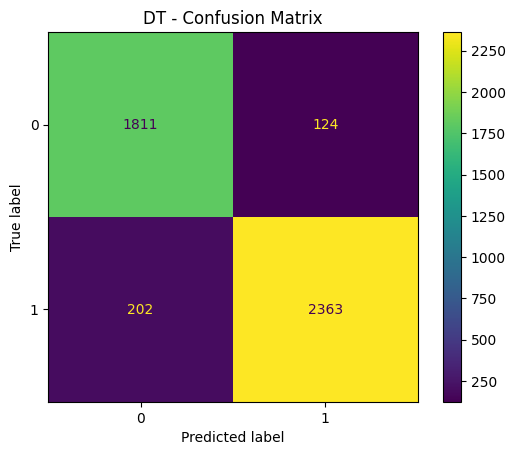

In [48]:
final_dt = DecisionTreeClassifier(
    max_depth=10, criterion='gini',
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42
)
final_dt.fit(X_train, y_train)
y_pred_dt = final_dt.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("DT - Confusion Matrix"); plt.show()

### 2. KNN

F1 no Teste: 0.9426
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1935
           1       0.94      0.94      0.94      2565

    accuracy                           0.93      4500
   macro avg       0.93      0.93      0.93      4500
weighted avg       0.93      0.93      0.93      4500



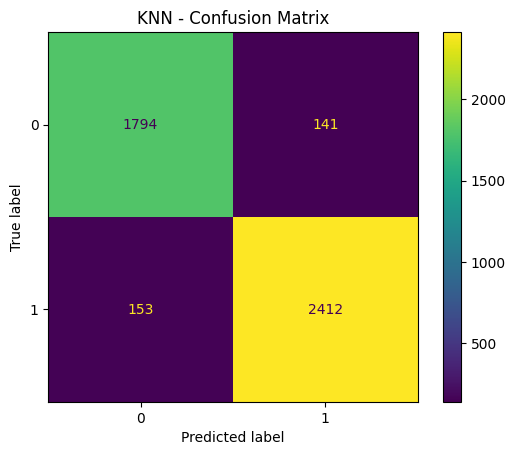

In [49]:
#O que foi feito: Optuna com hiperparâmetros: n_neighbors (3-30), weights (uniform/distance), metric (euclidean/manhattan/minkowski).
#3 trials ainda é pouco
#minkowski sem especificar p é equivalente a euclidean (p=2 por defeito). Estás a dar ao Optuna uma opção que é duplicada. Podes remover minkowski ou adicionar um p como hiperparâmetro separado.
#KNN não suporta class_weight — e o código não tenta usá-lo, o que está correto. Mas significa que o KNN é mais sensível ao desequilíbrio de classes do que os outros modelos. Podia ser mencionado no relatório.

final_knn = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='euclidean')
final_knn.fit(X_train, y_train)
y_pred_knn = final_knn.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN - Confusion Matrix"); plt.show()

### 3. Naive Bayes

F1 no Teste: 0.9555
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1935
           1       0.97      0.94      0.96      2565

    accuracy                           0.95      4500
   macro avg       0.95      0.95      0.95      4500
weighted avg       0.95      0.95      0.95      4500



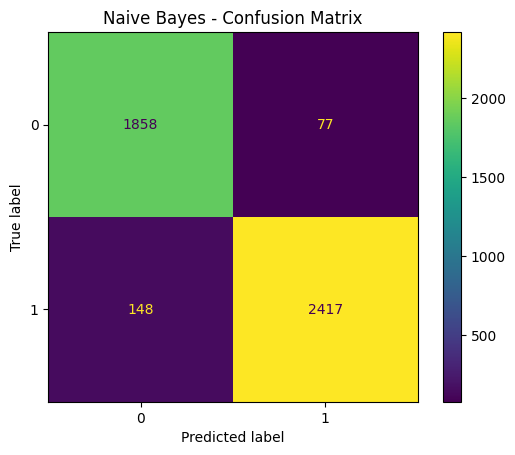

In [50]:
#Naive Bayes tem efetivamente poucos hiperparâmetros. O único relevante seria var_smoothing (suavização de variância), que podias tunar com Optuna se quisesses, mas não é obrigatório.
#GaussianNB não suporta class_weight. Para lidar com desequilíbrio podes usar priors manualmente para definir probabilidades a priori das classes. Mas para o relatório basta mencionar que o NB não tem suporte nativo para classes desbalanceadas.

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

print(f"F1 no Teste: {f1_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes - Confusion Matrix"); plt.show()

## Modelos
Modelos principais — Optuna com validation split, SEM cross_val_score:

### 1. NN

[I 2026-05-20 11:47:18,059] A new study created in memory with name: no-name-ddb0698e-4d24-4c9e-a5b9-5a4818b36a18
[I 2026-05-20 11:47:22,068] Trial 0 finished with value: 0.9514151730215431 and parameters: {'n_layers': 2, 'n_units_l0': 123, 'n_units_l1': 124, 'lr': 0.0001170909042450196, 'activation': 'tanh'}. Best is trial 0 with value: 0.9514151730215431.
[I 2026-05-20 11:47:25,268] Trial 1 finished with value: 0.9417139729455 and parameters: {'n_layers': 2, 'n_units_l0': 102, 'n_units_l1': 83, 'lr': 0.0876750924800937, 'activation': 'tanh'}. Best is trial 0 with value: 0.9514151730215431.
[I 2026-05-20 11:47:27,291] Trial 2 finished with value: 0.9270310559006211 and parameters: {'n_layers': 1, 'n_units_l0': 100, 'lr': 0.017103932264915293, 'activation': 'relu'}. Best is trial 0 with value: 0.9514151730215431.
[I 2026-05-20 11:47:32,647] Trial 3 finished with value: 0.916498972941233 and parameters: {'n_layers': 3, 'n_units_l0': 113, 'n_units_l1': 43, 'n_units_l2': 70, 'lr': 0.02365

Melhor F1 (val): 0.9514
Hiperparâmetros: {'n_layers': 2, 'n_units_l0': 57, 'n_units_l1': 119, 'lr': 0.00011324174421651264, 'activation': 'tanh'}
F1 no Teste: 0.9533
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1935
           1       0.96      0.95      0.95      2565

    accuracy                           0.95      4500
   macro avg       0.95      0.95      0.95      4500
weighted avg       0.95      0.95      0.95      4500



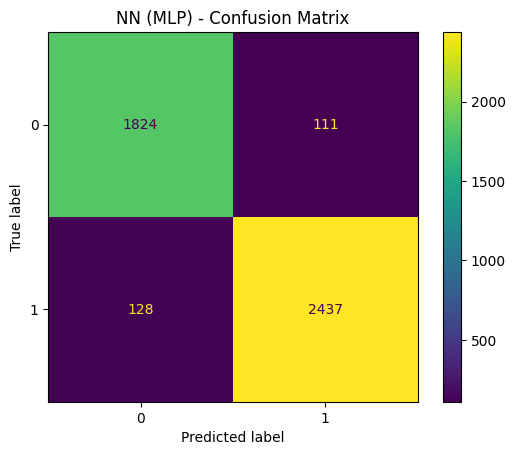

In [51]:
#O que foi feito: MLPClassifier do sklearn. Optuna com (5) trials. Hiperparâmetros: número de camadas (1-3), unidades por camada (4-128), learning rate. early_stopping=True.
# O max_iter=200 no Optuna e max_iter=500 no modelo final é inconsistente
# Não há otimização da função de ativação (activation: relu, tanh, logistic). Isto é um hiperparâmetro importante para MLPs.
# Não há otimização de momentum ou alpha (regularização L2). alpha é particularmente importante para controlar overfitting.
# early_stopping=True com cross_val_score tem uma interação subtil: o early stopping usa internamente um validation set dentro de cada fold, o que pode dar resultados ligeiramente diferentes do que esperas. Não é um erro grave, mas vale a pena estar ciente.

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_layers = [trial.suggest_int(f"n_units_l{i}", 16, 128) for i in range(n_layers)]
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    #?
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=trial.number
    )

    model = MLPClassifier(
        hidden_layer_sizes=tuple(hidden_layers),
        activation=activation,
        learning_rate_init=lr,
        max_iter=200,
        random_state=42,
        early_stopping=False #True?
    )
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

# Executar o estudo do Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
best_trial = study.best_trial

print(f"Melhor F1 (val): {best_trial.value:.4f}")
print("Hiperparâmetros:", best_trial.params)

n_layers_best = best_trial.params['n_layers']
hidden_best = tuple(best_trial.params[f'n_units_l{i}'] for i in range(n_layers_best))
final_nn = MLPClassifier(
    hidden_layer_sizes=hidden_best,
    activation=best_trial.params['activation'],
    learning_rate_init=best_trial.params['lr'],
    max_iter=500, random_state=42, early_stopping=True
)
final_nn.fit(X_train, y_train)
y_pred_nn = final_nn.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_nn):.4f}")
print(classification_report(y_test, y_pred_nn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn)
plt.title("NN (MLP) - Confusion Matrix"); plt.show()

In [52]:
#fazer pip install nbformat

# Gráfico com o histórico da otimização
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# Gráfico detalhando o impacto de cada hiperparâmetro
fig2 = optuna.visualization.plot_slice(study)
fig2.show()

### 2. SVM

[I 2026-05-20 11:48:10,312] A new study created in memory with name: no-name-2f22eb77-0e3b-490c-88df-714ab461ca69
[I 2026-05-20 11:48:10,380] Trial 0 finished with value: 0.9517306340383264 and parameters: {'C': 4.835859470195244, 'kernel': 'linear'}. Best is trial 0 with value: 0.9517306340383264.
[I 2026-05-20 11:48:10,467] Trial 1 finished with value: 0.950146339803292 and parameters: {'C': 11.249917458046415, 'kernel': 'linear'}. Best is trial 0 with value: 0.9517306340383264.
[I 2026-05-20 11:48:10,521] Trial 2 finished with value: 0.9333983732459077 and parameters: {'C': 1.8618225439627825, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9517306340383264.
[I 2026-05-20 11:48:10,566] Trial 3 finished with value: 0.9384540294649001 and parameters: {'C': 2.979549707288137, 'kernel': 'linear'}. Best is trial 0 with value: 0.9517306340383264.
[I 2026-05-20 11:48:10,640] Trial 4 finished with value: 0.9484883512368094 and parameters: {'C': 0.13114911311759114, 'kernel

Melhor F1 (val): 0.9517
Hiperparâmetros: {'C': 4.835859470195244, 'kernel': 'linear'}
F1 no Teste: 0.9550
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1935
           1       0.96      0.95      0.95      2565

    accuracy                           0.95      4500
   macro avg       0.95      0.95      0.95      4500
weighted avg       0.95      0.95      0.95      4500



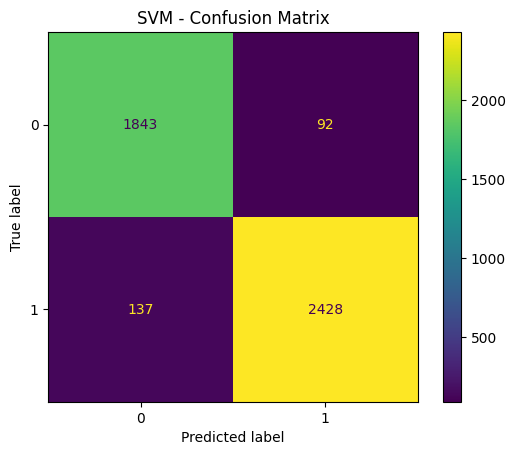

In [53]:
#O que foi feito: SVC com Optuna (5) trials. Hiperparâmetros: C (log-scale, 0.01 a 100), kernel (rbf/poly/sigmoid), gamma (scale/auto). class_weight='balanced'.
# Falta o kernel linear! Estás a testar rbf, poly e sigmoid mas não o kernel linear. Para dados tabulares normalizados, o kernel linear é frequentemente competitivo e é o mais interpretável
# O SVC por defeito usa estratégia One-vs-One (OvO) para multiclasse. Para 10 classes isso significa 45 classificadores binários treinados internamente. Funciona, mas é lento. Podes adicionar decision_function_shape='ovr' para One-vs-Rest, que é mais rápido

def objective_svm(trial):
    C      = trial.suggest_float('C', 1e-2, 1e2, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear'])
    gamma  = 'scale' if kernel == 'linear' else trial.suggest_categorical('gamma', ['scale', 'auto'])

    rng = np.random.default_rng(trial.number)
    idx = rng.choice(len(X_train), size=3000, replace=False)
    Xs, ys = X_train.iloc[idx], y_train.iloc[idx]

    X_tr, X_val, y_tr, y_val = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=42)
    model = SVC(C=C, kernel=kernel, gamma=gamma, class_weight='balanced', random_state=42)
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)
best_svm = study_svm.best_trial
print(f"Melhor F1 (val): {best_svm.value:.4f}")
print("Hiperparâmetros:", best_svm.params)

final_svm = SVC(**best_svm.params, class_weight='balanced', random_state=42)
final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM - Confusion Matrix"); plt.show()

### 3. [ Terceiro Método ]

##### a) Random Forest

[I 2026-05-20 11:48:12,054] A new study created in memory with name: no-name-1600b163-a25e-42f3-8a8e-b31bb6aa7f29
[I 2026-05-20 11:48:13,508] Trial 0 finished with value: 0.9490299886659235 and parameters: {'n_estimators': 195, 'max_depth': 17, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9490299886659235.
[I 2026-05-20 11:48:14,645] Trial 1 finished with value: 0.9462972183241403 and parameters: {'n_estimators': 278, 'max_depth': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9490299886659235.
[I 2026-05-20 11:48:15,350] Trial 2 finished with value: 0.9462154559850412 and parameters: {'n_estimators': 177, 'max_depth': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9490299886659235.
[I 2026-05-20 11:48:16,915] Trial 3 finished with value: 0.941820140260574 and parameters: {'n_estimators': 220, 'max_depth': 16, 'max_features': 'log2'}. Best is trial 0 with value: 0.9490299886659235.
[I 2026-05-20 11:48:17,741] Trial 4 finished with value: 0.94958167198298

Melhor F1 (val): 0.9510
Melhores Hiperparâmetros: {'n_estimators': 267, 'max_depth': 7, 'max_features': 'log2'}
F1 no Teste: 0.9530
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1935
           1       0.96      0.95      0.95      2565

    accuracy                           0.95      4500
   macro avg       0.94      0.95      0.95      4500
weighted avg       0.95      0.95      0.95      4500



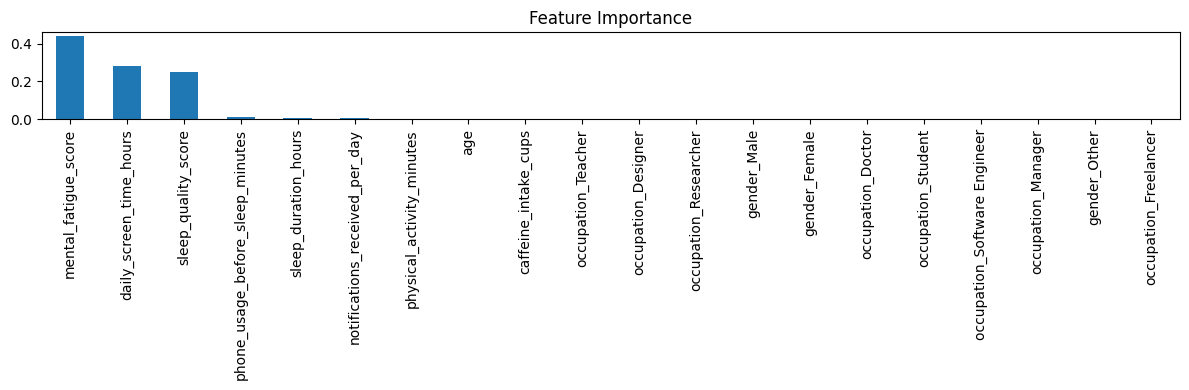

In [54]:
# O que foi feito: RandomForestClassifier com Optuna (5 trials). Hiperparâmetros: n_estimators (50-300), max_depth (3-20), min_samples_split, min_samples_leaf, max_features. class_weight='balanced'. Feature importance plot.
# max_features=None significa usar todas as features — isso é tecnicamente equivalente a uma "bagging ensemble" sem aleatoriedade de features, perdendo parte do que torna o RF robusto. Podes manter mas vale a pena notar.
# O range de max_depth (3-20) pode ser restritivo para 10 classes. Para o problema de 10 classes, podes alargar para 30.

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth    = trial.suggest_int('max_depth', 5, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=trial.number
    )
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        max_features=max_features, class_weight='balanced', random_state=42
    )
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)
best_rf = study_rf.best_trial
print(f"Melhor F1 (val): {best_rf.value:.4f}")
print("Melhores Hiperparâmetros:", best_rf.params)

final_rf = RandomForestClassifier(**best_rf.params, class_weight='balanced', random_state=42)
final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4), title='Feature Importance')
plt.tight_layout(); plt.show()

##### b) Logistic Regression

F1 no Teste: 0.9545
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1935
           1       0.96      0.95      0.95      2565

    accuracy                           0.95      4500
   macro avg       0.95      0.95      0.95      4500
weighted avg       0.95      0.95      0.95      4500



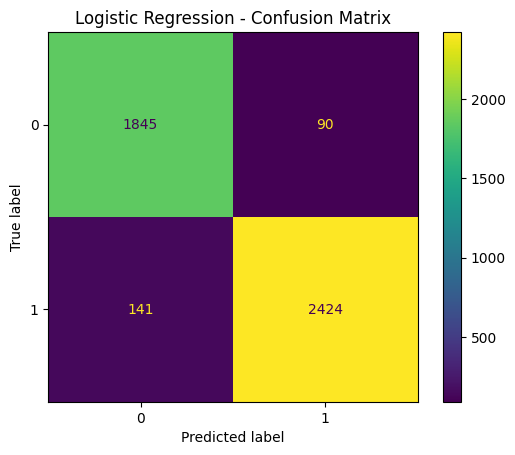

In [55]:
#O que foi feito: Optuna (5 trials). Hiperparâmetros: C, solver (lbfgs/saga). penalty='l2' hardcoded. class_weight='balanced'.
# O solver='saga' suporta tanto l1 como l2, mas o código força penalty='l2' para ambos. Isto desperdiça parte da capacidade do saga. Podias adicionar penalty como hiperparâmetro condicionado ao solver: se lbfgs → sempre l2; se saga → l1 ou l2.
# regressão logística não está nas aulas como um método de classificação explícito (o Word descreve "Regressão Linear" para outputs contínuos, não logística)
# Para multiclasse, o sklearn usa multi_class='auto' por defeito, que escolhe OvR ou multinomial dependendo do solver. Para saga podes usar multinomial explicitamente, o que é mais correto teoricamente para mais de 2 classes.

final_lr = LogisticRegression(
    C=1.0, solver='lbfgs', penalty='l2',
    class_weight='balanced', max_iter=1000, random_state=42
)
final_lr.fit(X_train, y_train)
y_pred_lr = final_lr.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression - Confusion Matrix"); plt.show()

##### c) Clustering como Classificadores

###### c.1) K-Means

K-Means (clf) F1 no Teste: 0.9496
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      1935
           1       0.98      0.92      0.95      2565

    accuracy                           0.94      4500
   macro avg       0.94      0.95      0.94      4500
weighted avg       0.95      0.94      0.94      4500



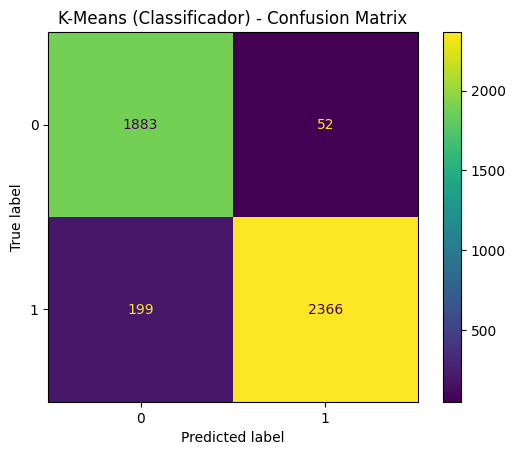

In [56]:
#O que foi feito: K-Means com k=2 nos features X. Mapeia cada cluster para a classe maioritária nos dados de treino. Prediz no teste atribuindo cada ponto ao centróide mais próximo.
# K-Means é aprendizagem não-supervisionada — não usa os labels durante o treino (errado)
# utilização criativa, mas metodologicamente fraca
# basta mudar n_clusters=5 ou n_clusters=10
km_clf = KMeans(n_clusters=2, random_state=42, n_init=10)
km_clf.fit(X_train)

# Mapear cluster → label maioritário
km_train_labels = km_clf.labels_
cluster_to_class = {}
for cluster_id in range(2):
    mask = km_train_labels == cluster_id
    majority = y_train.values[mask]
    cluster_to_class[cluster_id] = int(pd.Series(majority).mode()[0])

y_pred_km_clf = np.array([cluster_to_class[c] for c in km_clf.predict(X_test)])
print(f"K-Means (clf) F1 no Teste: {f1_score(y_test, y_pred_km_clf):.4f}")
print(classification_report(y_test, y_pred_km_clf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_km_clf)
plt.title("K-Means (Classificador) - Confusion Matrix"); plt.show()

###### c.2) AGNES (Hierarchical / Agglomerative)

AGNES F1 no Teste: 0.9467
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1935
           1       0.98      0.92      0.95      2565

    accuracy                           0.94      4500
   macro avg       0.94      0.94      0.94      4500
weighted avg       0.94      0.94      0.94      4500



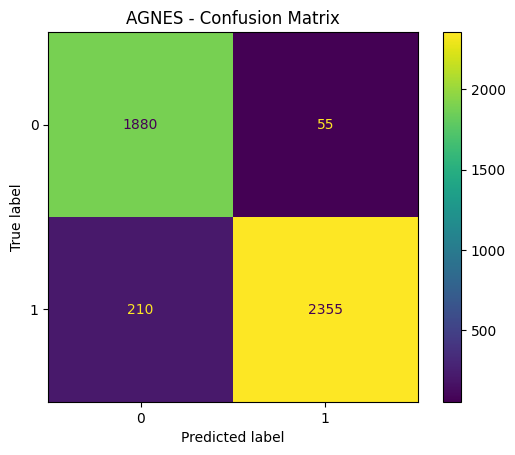

In [57]:
#O que foi feito: AgglomerativeClustering com linkage='ward', k=2. Calcula centróides manualmente e usa distância euclidiana para classificar.
# AgglomerativeClustering não tem predict() — a solução de usar cdist para centróides é correta como workaround.
# Mesmo problema conceptual do K-Means: não usa labels.
# linkage='ward' assume distâncias euclidianas — consistente com a métrica usada depois.
# bastar mudar n_clusters

agnes = AgglomerativeClustering(n_clusters=2, linkage='ward')
agnes_labels = agnes.fit_predict(X_train)

X_train_np = X_train.values
centroids_agnes = np.array([
    X_train_np[agnes_labels == i].mean(axis=0) for i in range(2)
])

cluster_to_class_agnes = {}
for cluster_id in range(2):
    mask = agnes_labels == cluster_id
    majority = y_train.values[mask]
    cluster_to_class_agnes[cluster_id] = int(pd.Series(majority).mode()[0])

dists = cdist(X_test.values, centroids_agnes, metric='euclidean')
nearest_clusters = dists.argmin(axis=1)
y_pred_agnes = np.array([cluster_to_class_agnes[c] for c in nearest_clusters])

print(f"AGNES F1 no Teste: {f1_score(y_test, y_pred_agnes):.4f}")
print(classification_report(y_test, y_pred_agnes))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_agnes)
plt.title("AGNES - Confusion Matrix"); plt.show()

## Comparação

                 F1 (Teste)
Decision Tree        0.9277
KNN                  0.9347
Naive Bayes          0.9501
NN (MLP)             0.9469
SVM                  0.9492
Random Forest        0.9470
Log. Regression      0.9487
K-Means (clf)        0.9444
AGNES                0.9413


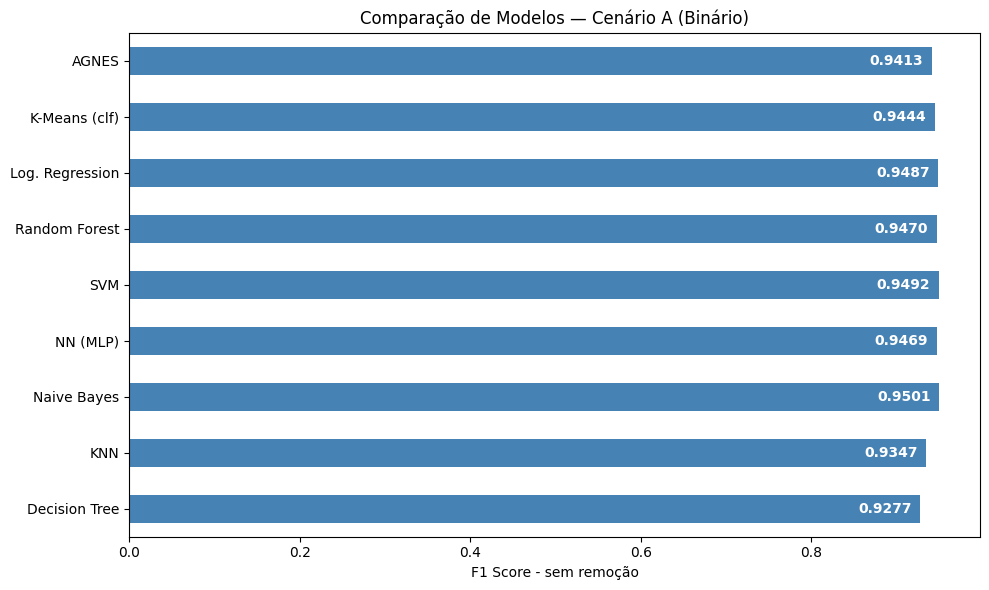

In [63]:
results = {
    'NN (MLP)':        f1_score(y_test, y_pred_nn, average='weighted'),
    'SVM':             f1_score(y_test, y_pred_svm,  average='weighted'),
    'Random Forest':   f1_score(y_test, y_pred_rf, average='weighted'),
    'Decision Tree':   f1_score(y_test, y_pred_dt, average='weighted'),
    'KNN':             f1_score(y_test, y_pred_knn, average='weighted'),
    'Naive Bayes':     f1_score(y_test, y_pred_nb, average='weighted'),
    'Log. Regression': f1_score(y_test, y_pred_lr, average='weighted'),
    'K-Means (clf)':   f1_score(y_test, y_pred_km_clf, average='weighted'),
    'AGNES':           f1_score(y_test, y_pred_agnes, average='weighted'),
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1 (Teste)'])
desired_order = [
    'Decision Tree',
    'KNN',
    'Naive Bayes',
    'NN (MLP)',
    'SVM',
    'Random Forest',
    'Log. Regression',
    'K-Means (clf)',
    'AGNES'
]
results_df = results_df.reindex(desired_order)
print(results_df.round(4))

ax = results_df.plot(kind='barh', figsize=(10, 6), legend=False, color='steelblue')
plt.xlabel('F1 Score - sem remoção')
plt.title('Comparação de Modelos — Cenário A (Binário)')

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['F1 (Teste)'] - 0.01, i, f"{row['F1 (Teste)']:.4f}", 
            va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()